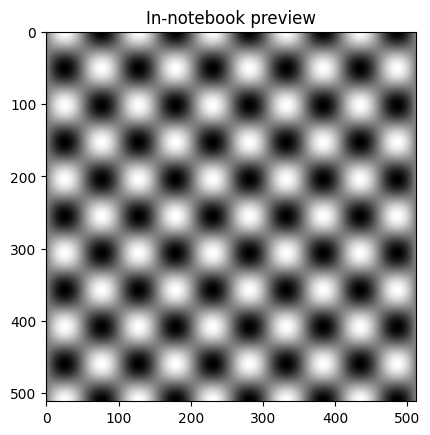

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from image_viewer_app import launch_image_viewer

%matplotlib inline

# Example: synthetic test image
x = np.linspace(0, 1, 512)
y = np.linspace(0, 1, 512)
X, Y = np.meshgrid(x, y)
img = np.sin(10 * np.pi * X) * np.cos(10 * np.pi * Y)

# Show in notebook just to check (optional)
plt.imshow(img, cmap="gray")
plt.title("In-notebook preview")
plt.show()

# Launch external viewer (non-blocking, own process)
launch_image_viewer(img, title="Hilbert test pattern 1")
launch_image_viewer(np.log(2+img), title="Hilbert test pattern 2")


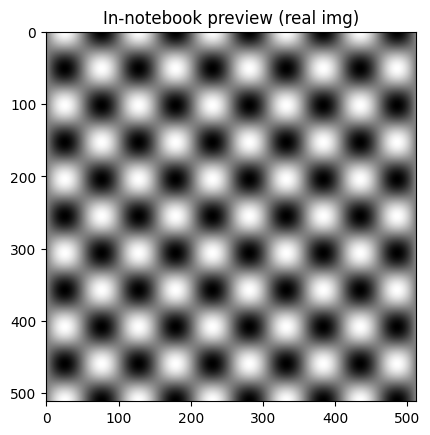

In [2]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from image_viewer_app import launch_image_viewer

# --- Example: synthetic test image (real) ---
x = np.linspace(0, 1, 512)
y = np.linspace(0, 1, 512)
X, Y = np.meshgrid(x, y)
img = np.sin(10 * np.pi * X) * np.cos(10 * np.pi * Y)

# In-notebook preview (optional)
plt.imshow(img, cmap="gray")
plt.title("In-notebook preview (real img)")
plt.show()

# --- Build a complex TensorFlow "image" ---
# Use the real img as amplitude, and create a smooth phase ramp
img_tf = tf.convert_to_tensor(img, dtype=tf.float32)

phase_tf = 2.0 * np.pi * tf.convert_to_tensor(X, dtype=tf.float32) + 0.5 * np.pi * tf.convert_to_tensor(Y, dtype=tf.float32)

# complex image: z = img * exp(j*phase)
z_tf = tf.cast(img_tf, tf.complex64) * tf.exp(1j * tf.cast(phase_tf, tf.complex64))

# --- Compute magnitude and phase (TensorFlow) ---
mag_tf = tf.abs(z_tf)
ph_tf  = tf.math.angle(z_tf)   # phase in [-pi, pi]

# Convert to NumPy for the viewer process
mag = mag_tf.numpy()
ph  = ph_tf.numpy()

# --- Launch external viewers (non-blocking, separate process) ---
launch_image_viewer(mag, title="TF complex image |z| (magnitude)")
launch_image_viewer(ph,  title="TF complex image ∠z (phase)")
